# 🔮 Step 4: Prediction & Analysis

Use the trained model to classify new images and calculate areas.

## What This Notebook Does:
- ✅ Load trained CNN model
- ✅ Load new/test satellite images
- ✅ Make predictions
- ✅ Visualize results
- ✅ Calculate area changes (km²)

---

**Previous:** [03_model_training.ipynb](03_model_training.ipynb)  
**Next:** [05_visualization_reports.ipynb](05_visualization_reports.ipynb)

## Load Model and Data

In [6]:
# Cell: Load Model and Data

import rasterio
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler

# Load trained model
print("📂 Loading trained model...")
model = joblib.load("outputs/coastal_classifier_model.pkl")
scaler = joblib.load("outputs/feature_scaler.pkl")

# Load metadata
print("📂 Loading metadata...")
with open("outputs/model_metadata.json") as f:
    metadata = json.load(f)

# Use 'classes' instead of 'class_names'
class_names = {i: str(name) for i, name in enumerate(metadata['classes'])}

print(f"✅ Model loaded!")
print(f"   Test Accuracy: {metadata['test_accuracy']*100:.2f}%")
print(f"   Classes: {list(class_names.values())}")

📂 Loading trained model...
📂 Loading metadata...
✅ Model loaded!
   Test Accuracy: 89.15%
   Classes: ['1', '2', '3', '4']


## Load New Images for Prediction

*For this demo, using the same images. In production, load different year's data.*

In [7]:
# Load bands (for demo, using same images - replace with new year's data)
print("📂 Loading images...")
new_B02 = rasterio.open("coastalImage/B02.tiff").read(1).astype(float)
new_B03 = rasterio.open("coastalImage/B03.tiff").read(1).astype(float)
new_B04 = rasterio.open("coastalImage/B04.tiff").read(1).astype(float)
new_B08 = rasterio.open("coastalImage/B08.tiff").read(1).astype(float)

# Calculate NDVI
new_ndvi = (new_B08 - new_B04) / (new_B08 + new_B04 + 1e-10)

# Store shape for reshaping
original_shape = new_B02.shape

# Flatten and prepare
new_data = np.stack([
    new_B02.flatten(),
    new_B03.flatten(),
    new_B04.flatten(),
    new_B08.flatten(),
    new_ndvi.flatten()
], axis=1)

new_X = new_data.reshape(-1, 5, 1)

print(f"✅ Images loaded!")
print(f"   Shape: {original_shape}")
print(f"   Pixels: {new_X.shape[0]:,}")

📂 Loading images...
✅ Images loaded!
   Shape: (424, 480)
   Pixels: 203,520


## Make Predictions and Reshape

In [8]:
# Cell: Make Predictions and Reshape

# Load the processed image with all 7 bands
print("📂 Loading processed image...")
with rasterio.open("processed_image_with_indices.tif") as src:
    image_data = src.read()
    profile = src.profile.copy()

print(f"Making predictions on processed image...")
print(f"Image shape: {image_data.shape}")

# Reshape: (7, H, W) -> (H*W, 7)
bands, height, width = image_data.shape
reshaped_img = image_data.reshape(bands, -1).T 

# Handle NaNs
reshaped_img = np.nan_to_num(reshaped_img, nan=0)

# Scale using the saved scaler
reshaped_img_scaled = scaler.transform(reshaped_img)

# Predict!
print("🔮 Making predictions... (this may take a minute)")
prediction_flat = model.predict(reshaped_img_scaled)

# Reshape back to map: (H*W) -> (H, W)
prediction_map = prediction_flat.reshape(height, width)

print(f"✅ Predictions complete!")
print(f"   Predicted classes: {np.unique(prediction_flat)}")

📂 Loading processed image...
Making predictions on processed image...
Image shape: (7, 424, 480)
🔮 Making predictions... (this may take a minute)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s


✅ Predictions complete!
   Predicted classes: [1 2 3 4]


[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.2s finished


## Save and Visualize

✅ Map saved as 'final_classification_map.tif'


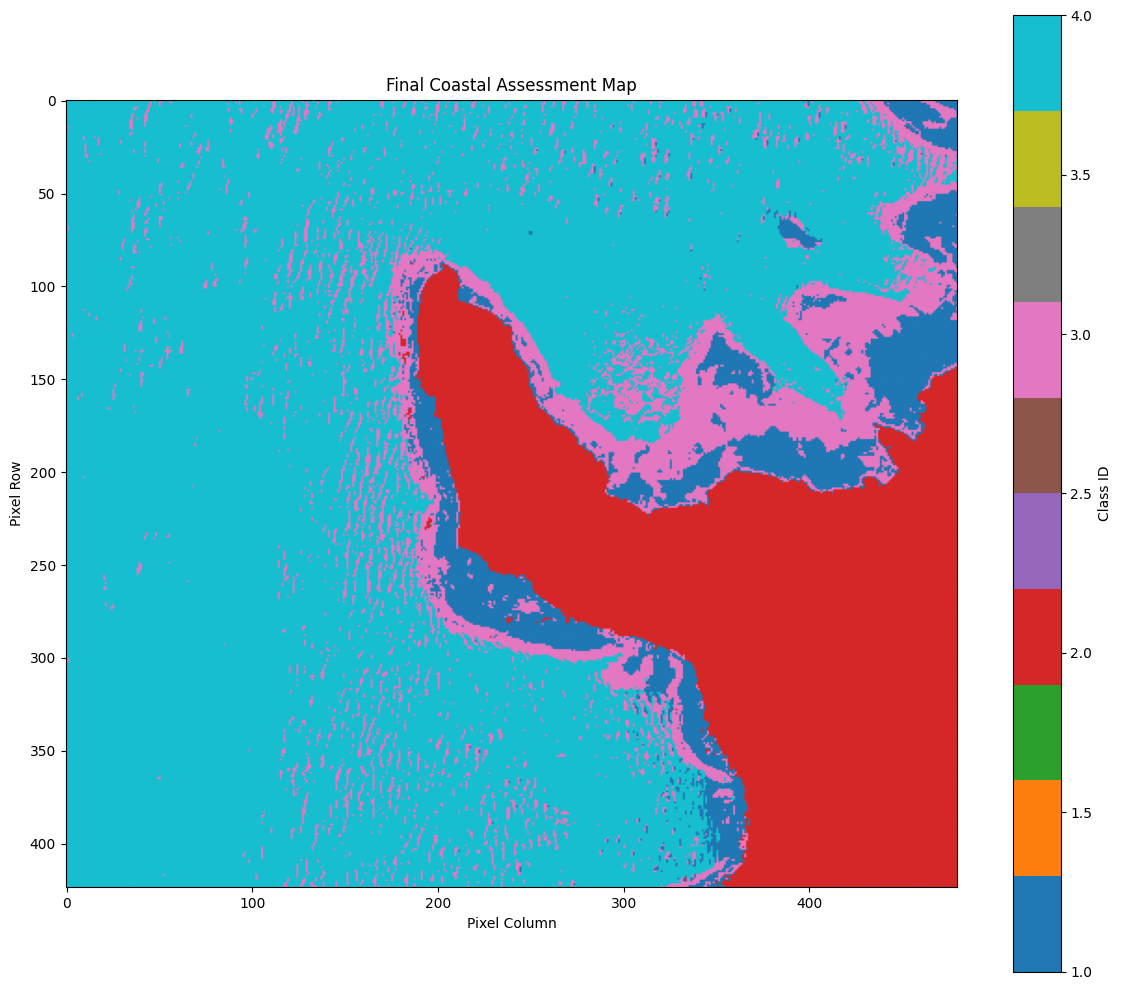


📋 Labels Mapping:
   Class 1: 1
   Class 2: 2
   Class 3: 3
   Class 4: 4


In [9]:
# Cell: Save and Visualize

import rasterio
from rasterio.transform import Affine

# Load the original processed image to get geospatial metadata
with rasterio.open("processed_image_with_indices.tif") as src:
    profile = src.profile.copy()
    transform = src.transform

# Update profile for single-band output
profile.update(count=1, dtype=rasterio.uint8, nodata=None)

# Map prediction classes to numeric IDs for GeoTIFF
unique_labels = np.unique(prediction_flat)
label_to_id = {label: i for i, label in enumerate(unique_labels, 1)}
prediction_numeric = np.vectorize(label_to_id.get)(prediction_map).astype(rasterio.uint8)

# Save as GeoTIFF
with rasterio.open("final_classification_map.tif", 'w', **profile) as dst:
    dst.write(prediction_numeric, 1)

print("✅ Map saved as 'final_classification_map.tif'")

# Visualize
plt.figure(figsize=(12, 10))
plt.imshow(prediction_numeric, cmap='tab10')
plt.colorbar(label='Class ID')
plt.title("Final Coastal Assessment Map")
plt.xlabel("Pixel Column")
plt.ylabel("Pixel Row")
plt.tight_layout()
plt.show()

print("\n📋 Labels Mapping:")
for label, id_num in label_to_id.items():
    print(f"   Class {id_num}: {label}")

## Calculate Area by Class

In [10]:
# Cell: Calculate Area by Class

import pandas as pd

# 1. Define Pixel Size for Sentinel-2
pixel_size_meters = 10
area_per_pixel_sqm = pixel_size_meters * pixel_size_meters  # 100 m²

# 2. Count the pixels for each class
# 'prediction_flat' comes from the model.predict() step in the previous cell
unique_labels, counts = np.unique(prediction_flat, return_counts=True)

# 3. Create a Summary Table
results = []

for label, count in zip(unique_labels, counts):
    area_sqm = count * area_per_pixel_sqm
    area_hectares = area_sqm / 10000       # 10,000 m² = 1 Hectare
    area_sqkm = area_sqm / 1e6             # 1,000,000 m² = 1 km²
    
    results.append({
        "Class Name": label,
        "Pixel Count": count,
        "Area (m²)": f"{area_sqm:,.0f}",
        "Area (Hectares)": f"{area_hectares:,.2f}",
        "Area (km²)": f"{area_sqkm:,.4f}"
    })

# 4. Display as a clean DataFrame
area_df = pd.DataFrame(results)
print("--- 📊 Coastal Assessment Area Report ---")
print(area_df.to_string(index=False))

# Optional: Save report to CSV
area_df.to_csv("final_area_report.csv", index=False)

print("\n💾 Results saved to 'final_area_report.csv'")
print("\n" + "="*60)
print("✅ PREDICTION & ANALYSIS COMPLETE!")
print("="*60)
print("\n📌 Next Step: Open 05_visualization_reports.ipynb for multi-year trends")

--- 📊 Coastal Assessment Area Report ---
 Class Name  Pixel Count  Area (m²) Area (Hectares) Area (km²)
          1        13564  1,356,400          135.64     1.3564
          2        44740  4,474,000          447.40     4.4740
          3        21996  2,199,600          219.96     2.1996
          4       123220 12,322,000        1,232.20    12.3220

💾 Results saved to 'final_area_report.csv'

✅ PREDICTION & ANALYSIS COMPLETE!

📌 Next Step: Open 05_visualization_reports.ipynb for multi-year trends
